In [1]:
# capstone project, week 1

import numpy as np
import warnings
import matplotlib.pyplot as plt

from bayes_tools import (normalize, initial_bounds, generate_next_point, ucb_acquisition)
from viz_tools import (plot_1d, plot_2d)

# Function 1

In [2]:
X = np.load("initial_data/function_1/initial_inputs.npy")
y = np.load("initial_data/function_1/initial_outputs.npy")

In [3]:
# Get some info about what we loaded

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

bounds = initial_bounds(X, pad_fraction=1.0)
print("\nBounds: ", bounds)



X shape: (10, 2)
y shape: (10,)
X range per dimension:
  min: [0.08250725 0.07872278]
  max: [0.88388983 0.8798981 ]
y range: -0.0036060626443634764 to 7.710875114502849e-16

Bounds:  [[-0.71887533  1.68527241]
 [-0.72245255  1.68107343]]


In [4]:
x_next, gp = generate_next_point(
    X, y, bounds,
    acquisition="ucb",
    kappa=5.0,          # exploration-heavy
    maximize=True,
    n_restarts=25,
    random_state=0,
)

print("\n--- Next point to evaluate (bounds = [0,1]^3) ---")
print("x_next:", np.round(x_next, 4))

mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"GP predicted mean: {mu[0]:.4f}, predicted std: {sigma[0]:.4f}")


--- Next point to evaluate (bounds = [0,1]^3) ---
x_next: [0.7606 0.1997]
GP predicted mean: -0.0004, predicted std: 0.0011


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


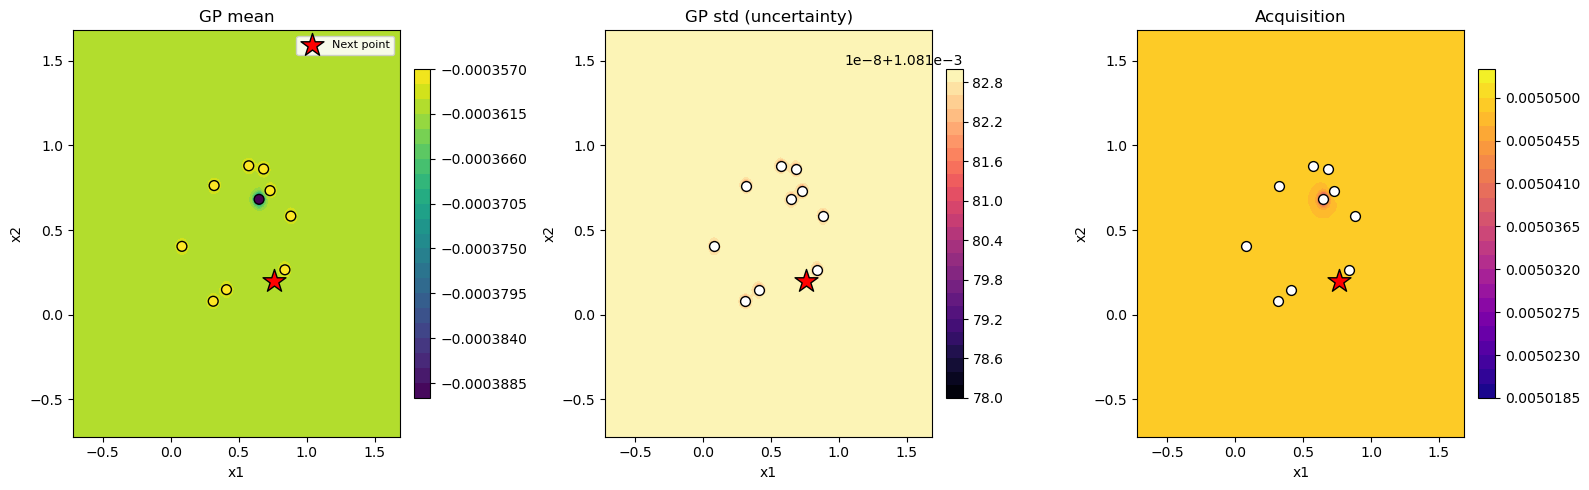

In [5]:
fig = plot_2d(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": 5.0, "maximize": True},
)
plt.show()

# Function 2

In [6]:
X = np.load("initial_data/function_2/initial_inputs.npy")
y = np.load("initial_data/function_2/initial_outputs.npy")


print("X shape:", X.shape)
print("y shape:", y.shape)
print("X range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

bounds = initial_bounds(X, pad_fraction=1.0)
print("\nBounds: ", bounds)



X shape: (10, 2)
y shape: (10,)
X range per dimension:
  min: [0.14269907 0.02869772]
  max: [0.87779099 0.9265642 ]
y range: -0.06562362443733738 to 0.6112052157614438

Bounds:  [[-0.59239284  1.6128829 ]
 [-0.86916876  1.82443068]]


In [7]:
x_next, gp = generate_next_point(
    X, y, bounds,
    acquisition="ucb",
    kappa=5.0,          # exploration-heavy
    maximize=True,
    n_restarts=25,
    random_state=0,
    gp_kwargs={"n_restarts_optimizer": 20},
)

print("\n--- Next point to evaluate (bounds = [0,1]^3) ---")
print("x_next:", np.round(x_next, 4))
print(gp.kernel_)

mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"GP predicted mean: {mu[0]:.4f}, predicted std: {sigma[0]:.4f}")


--- Next point to evaluate (bounds = [0,1]^3) ---
x_next: [0.8336 1.0505]
1.04**2 * Matern(length_scale=0.0549, nu=2.5) + WhiteKernel(noise_level=1e-06)
GP predicted mean: 0.4060, predicted std: 0.2188


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


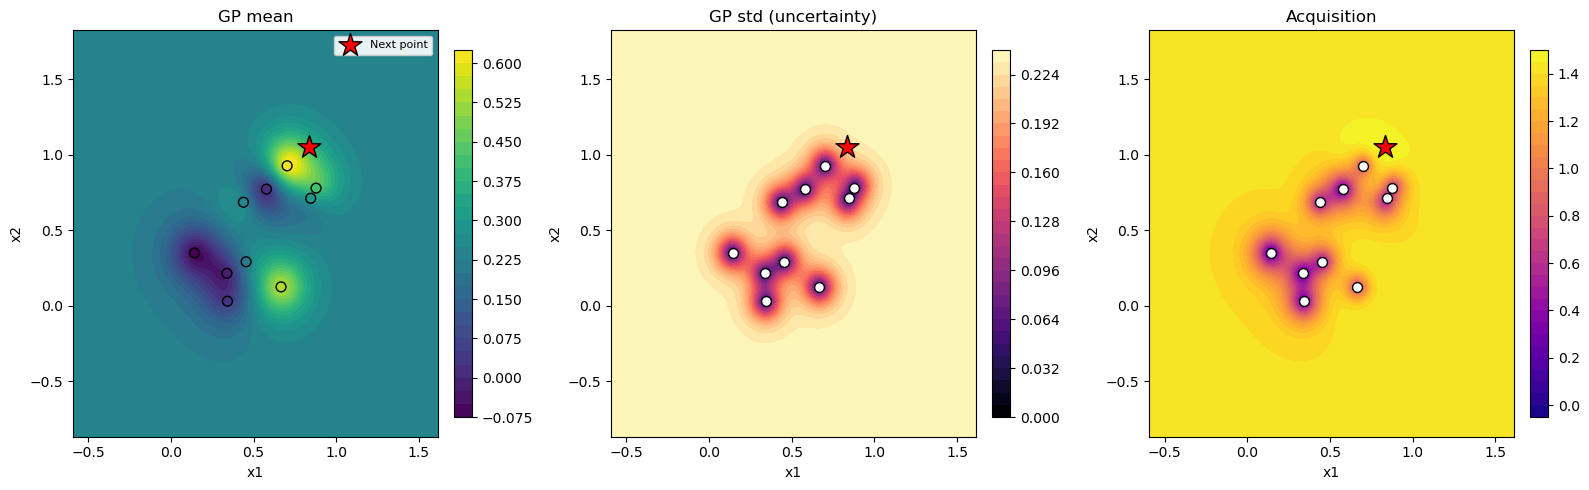

In [8]:
fig = plot_2d(
     X, y, bounds, gp,
     acquisition_fn=ucb_acquisition,
     x_next=x_next,
     acq_kwargs={"kappa": 5.0, "maximize": True},
)

plt.show()

# Generalise to get all of them... 

In [11]:
acquisitions = {
    1: "ucb",
    2: "ucb",
    3: "pi",
    4: "pi",
    5: "pi",
    6: "pi",
    7: "pi",
    8: "pi"}
    

for n in range(1, 9):
    inf = f"initial_data/function_{n}/initial_inputs.npy"
    outf = f"initial_data/function_{n}/initial_outputs.npy"

    X = np.load(inf)
    y = np.load(outf)
    bounds = initial_bounds(X, pad_fraction=1.0)   # <-- add this

    x_next, gp = generate_next_point(
        X, y, bounds,
        acquisition=acquisitions[n],
        kappa=5.0,
        maximize=True,
        n_restarts=25,
        random_state=0,
        gp_kwargs={"n_restarts_optimizer": 20},
    )

    print(f"\n--- Function {n}: next point to evaluate (bounds shape {bounds.shape}) ---")
    print("x_next:", np.round(x_next, 6))
    

/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



--- Function 1: next point to evaluate (bounds shape (2, 2)) ---
x_next: [0.760601 0.199726]

--- Function 2: next point to evaluate (bounds shape (2, 2)) ---
x_next: [0.833607 1.050529]


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



--- Function 3: next point to evaluate (bounds shape (3, 2)) ---
x_next: [0.270875 0.2582   0.418474]


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



--- Function 4: next point to evaluate (bounds shape (4, 2)) ---
x_next: [-0.909972 -0.907092  1.836169  1.917449]

--- Function 5: next point to evaluate (bounds shape (4, 2)) ---
x_next: [0.25621  0.903056 1.105882 1.065351]


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



--- Function 6: next point to evaluate (bounds shape (5, 2)) ---
x_next: [0.519691 0.384667 0.382026 0.764661 0.218558]

--- Function 7: next point to evaluate (bounds shape (6, 2)) ---
x_next: [ 0.273698  1.11042   1.04745   1.667513 -0.629585  1.119339]


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



--- Function 8: next point to evaluate (bounds shape (8, 2)) ---
x_next: [0.095333 0.261314 0.113603 0.282728 0.586936 0.54168  0.291424 0.603135]
